# Exploring the AION-1 embedding space

Scratchpad for `aion-embedding-structure`. This notebook is **not** part of the
analysis: nothing here produces a declared artifact and nothing here carries a
provenance manifest. Materialized results come from `lc run` and live under
`analyses/<sub>/results/<universe>/<output_id>/`.

What it *does* do is import `src/lcommon.py`, the same module every recipe uses.
So when you apply a quality cut or a target transform here, you get exactly the
decision the pipeline applies — exploration and results cannot quietly diverge.

**Kernel:** `aion-embedding-structure (.venv)`.

### Contents
| § | |
|---|---|
| 1 | Setup and thread budget |
| 2 | Data inventory |
| 3 | Applying the spec's decisions |
| 4 | Global geometry of the embedding cloud |
| 5 | 2-D projections (PCA / UMAP / t-SNE) |
| 6 | Rotation orbits |
| 7 | Real vs simulated |
| 8 | Quick probe scratchpad |

## 1 · Setup

**Run this cell first.** It caps BLAS/OpenMP threads *before* numpy is imported.
That matters: the box has 20 cores but only a few GB free, and an `lc run` may be
in flight. Unbounded fan-out here starves it and has OOM'd this machine before.
Raise `N_THREADS` if nothing else is running.

In [1]:
import sys, os
# --- environment guard -------------------------------------------------
# This notebook must run on the project .venv, not on a system/Anaconda
# Python. Wrong interpreter = different pandas, no umap, and cells that fail
# for reasons that have nothing to do with the analysis.
_EXPECT = "my-analysis/.venv"
if _EXPECT not in sys.executable:
    raise SystemExit(
        "WRONG KERNEL.\n"
        f"  running on : {sys.executable}\n"
        f"  expected   : .../{_EXPECT}/bin/python\n\n"
        "Fix: kernel picker (top right) -> 'aion-embedding-structure (.venv)'.\n"
        "If it is not listed, reload the VSCode window."
    )
# -----------------------------------------------------------------------

N_THREADS = 4                      # keep low while `lc run` is working
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_v] = str(N_THREADS)

import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "astra.yaml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
import lcommon as lc                # the pipeline's own decision implementations

KIT   = ROOT / "KAAI-2026-Hackathon"
OBS   = KIT / "observational-data"
SIM   = KIT / "astrid-data"
CACHE = ROOT / "previews" / "nb-cache"; CACHE.mkdir(parents=True, exist_ok=True)

%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({"figure.dpi": 110, "font.size": 13, "axes.grid": True,
                     "grid.alpha": .5, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
warnings.filterwarnings("ignore", category=FutureWarning)
print("project :", ROOT)
print("threads :", N_THREADS, "| seed:", lc.SEED)

project : /home/mgurgeni/projects/my-analysis
threads : 4 | seed: 20260902


## 2 · Data inventory

The 4 GB image cubes are memory-mapped, so `anchor_images` costs nothing until
you index it. Everything else is small enough to load outright.

Row `i` of an embedding array is row `i` of its catalogue — that alignment holds
everywhere in the kit. The anchor and gzArm samples are **different galaxies**
and must never be merged.

In [2]:
def load():
    d = {}
    d["anchor_emb"] = np.load(OBS / "anchorEImg.npy")
    d["anchor_cat"] = pd.read_parquet(OBS / "anchor.parquet")
    d["gzarm_emb"]  = np.load(OBS / "gzArmEImg.npy")
    d["gzarm_cat"]  = pd.read_parquet(OBS / "gzArm.parquet")
    d["astrid_emb"] = np.load(SIM / "astridEImg.npy")
    d["astrid_cat"] = pd.read_parquet(SIM / "astrid.parquet")
    d["anchor_img"] = np.load(OBS / "anchorFlux.npy", mmap_mode="r")   # 4 GB, lazy
    d["astrid_img"] = np.load(SIM / "astridImages.npy", mmap_mode="r")
    return d

D = load()

for k, v in D.items():
    print(f"{k:12s} {str(getattr(v,'shape',(len(v),len((v))))):>22s}  {type(v).__name__}")

anchor_emb            (10000, 1024)  ndarray
anchor_cat             (10000, 190)  DataFrame
gzarm_emb             (10000, 1024)  ndarray
gzarm_cat               (10000, 46)  DataFrame
astrid_emb            (10000, 1024)  ndarray
astrid_cat              (10000, 18)  DataFrame
anchor_img     (10000, 4, 160, 160)  memmap
astrid_img       (10000, 4, 96, 96)  memmap


In [3]:
# Column coverage — the reason morphology comes from gzArm, not anchor.
def coverage(df, cols):
    rows = []
    for c in cols:
        if c not in df.columns:
            rows.append((c, "absent", np.nan)); continue
        s = pd.to_numeric(df[c], errors="coerce")
        rows.append((c, f"{s.notna().mean():.1%}", float(s.median())))
    return pd.DataFrame(rows, columns=["column", "coverage", "median"])

print("ANCHOR — physical targets are full coverage, morphology is not:")
display(coverage(D["anchor_cat"],
    ["logMstar","avgSfr","tageMw","zMw","redshift","paDeg","shapeDefined",
     "spiralArmsFraction","bulgeDominantFraction","mergerFraction"]))
print("gzARM — morphology at essentially full coverage:")
display(coverage(D["gzarm_cat"], lc.MORPH_LABELS))

ANCHOR — physical targets are full coverage, morphology is not:


,column,coverage,median
0,logMstar,100.0%,10.771732
1,avgSfr,100.0%,0.954708
2,tageMw,100.0%,9.047825
3,zMw,100.0%,0.005466
4,redshift,100.0%,0.236329
5,paDeg,100.0%,68.336951
6,shapeDefined,100.0%,1.000000
7,spiralArmsFraction,1.9%,0.891917
8,bulgeDominantFraction,1.9%,0.011423
9,mergerFraction,32.1%,0.016908


gzARM — morphology at essentially full coverage:


,column,coverage,median
0,spiralArmsFraction,100.0%,0.881251
1,barStrongFraction,100.0%,0.102059
2,barWeakFraction,100.0%,0.320127
3,edgeOnFraction,100.0%,0.034467
4,bulgeDominantFraction,100.0%,0.011383
5,mergerFraction,100.0%,0.022268


## 3 · Applying the spec's decisions

`lcommon` is the single implementation of every decision in `astra.yaml`. Use it
rather than re-deriving cuts by hand, otherwise your exploration and the
materialized numbers answer different questions.

The active baseline settings live in `universes/baseline.yaml` plus one file per
sub-analysis under `analyses/<sub>/universes/`.

In [4]:
import yaml
U = yaml.safe_load((ROOT / "universes" / "baseline.yaml").read_text())
SUBU = {n: yaml.safe_load((ROOT/"analyses"/n/"universes"/"baseline.yaml").read_text())
        for n in ("probes", "manifold", "domain_gap")}
DEC = dict(U["decisions"])
for n, s in SUBU.items():
    DEC.update({f"{n}.{k}": v for k, v in s["decisions"].items()})
pd.set_option("display.max_rows", 60)
display(pd.Series(DEC, name="baseline").to_frame())

,baseline
embedding_preprocessing,standardize
eval_split,kfold_5
real_quality_cuts,standard
target_transform,log_ssfr
probe_model,ridge
probe_regularization,cv_grid
probes.photometry_baseline_features,mags_colours
probes.morphology_label_form,threshold_median
probes.nuisance_feature_set,psf_depth_ebv
manifold.orbit_subsample,n512


In [5]:
# The same cut and transform the probes use.
PREP = DEC["embedding_preprocessing"]          # 'standardize'
CUTS = DEC["real_quality_cuts"]                # 'standard'
TT   = DEC["target_transform"]                 # 'log_ssfr'

targets, tnames = lc.transform_targets(D["anchor_cat"], TT)
mask = lc.real_cut_mask(D["anchor_cat"], CUTS, target_cols=lc.PHYSICAL_TARGETS)
print(f"real_quality_cuts='{CUTS}' keeps {mask.sum()} / {len(mask)} anchor galaxies")
print(f"target_transform='{TT}' gives:", {k: tnames[k] for k in tnames})

X   = D["anchor_emb"][mask].astype(np.float64)
cat = D["anchor_cat"][mask].reset_index(drop=True)
Y   = {k: v[mask] for k, v in targets.items()}
Xz  = lc.EmbeddingPreprocessor(PREP).fit_transform(X)
print("conditioned embedding:", Xz.shape)

real_quality_cuts='standard' keeps 8058 / 10000 anchor galaxies
target_transform='log_ssfr' gives: {'logMstar': 'logMstar', 'avgSfr': 'log_sSFR', 'tageMw': 'tageMw', 'zMw': 'log_zMw', 'redshift': 'redshift'}
conditioned embedding: (8058, 1024)


## 4 · Global geometry

Two numbers that say different things. **PCA participation ratio** counts
directions of variance — it measures the ambient linear subspace. **TwoNN**
estimates the dimension of the manifold the points actually lie on, tolerating
curvature. Ansuini et al. find the linear number one to two orders of magnitude
larger, and that gap is the point: it is evidence of curvature, not a
disagreement about the same quantity.

Above ID ≈ 20 TwoNN underestimates, so a large value is a **lower bound**.

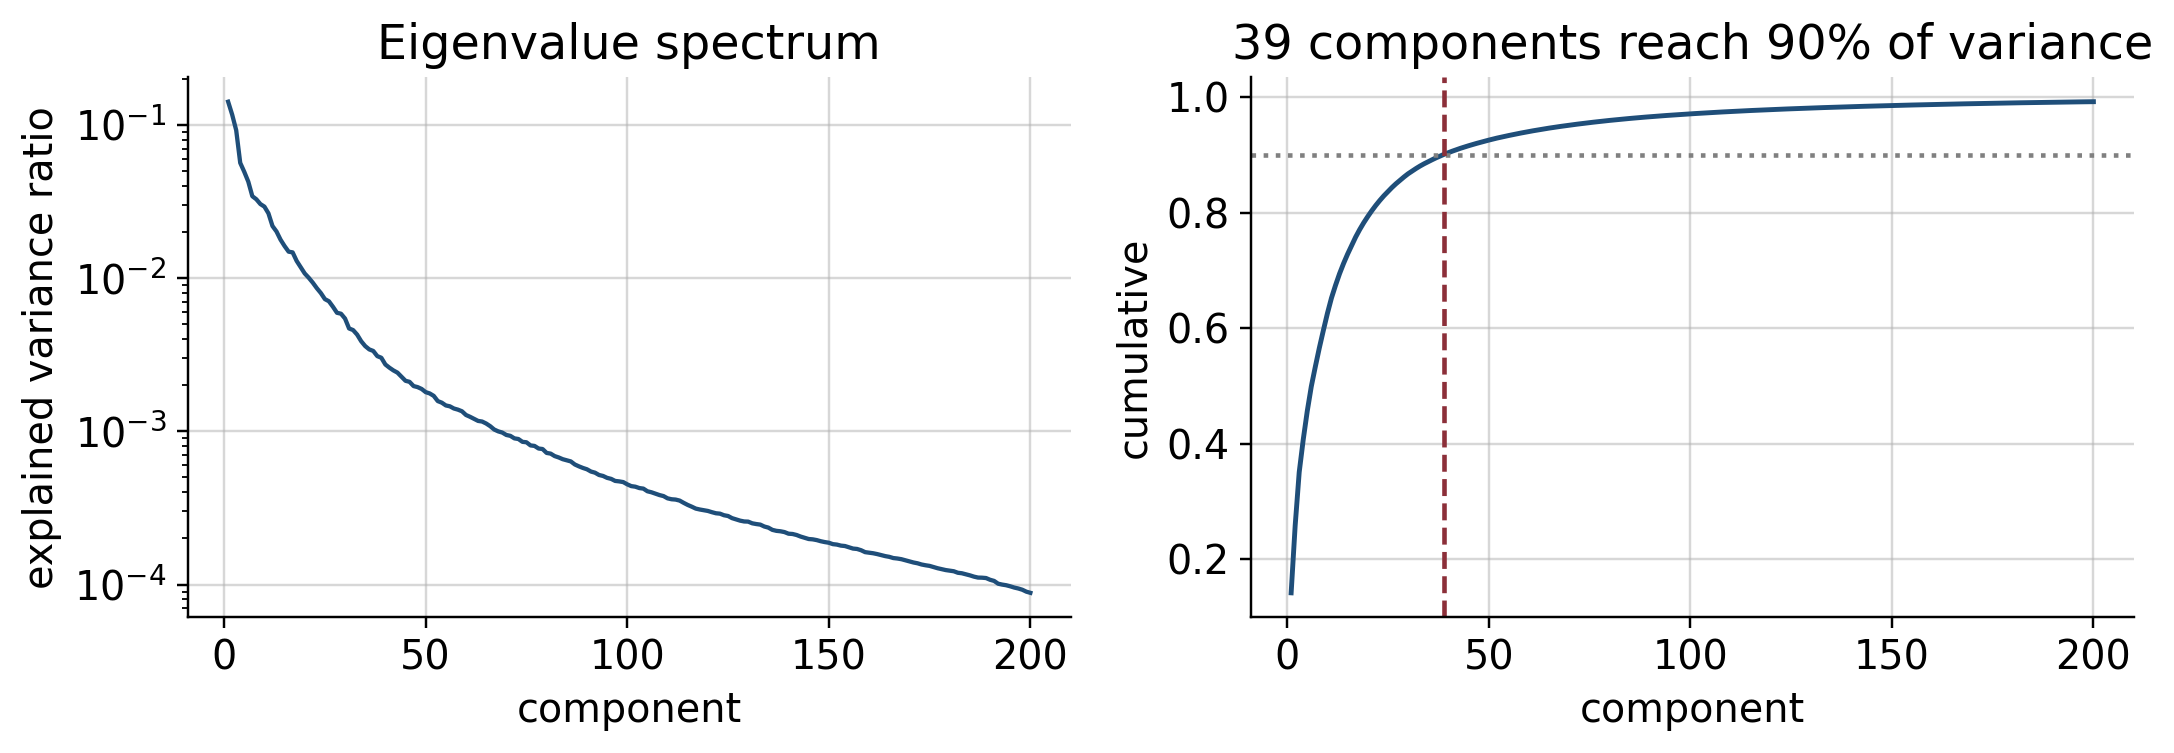

PCA participation ratio : 17.4
components for 90% var  : 39


In [6]:
from sklearn.decomposition import PCA
p = PCA(n_components=200, random_state=lc.SEED).fit(Xz)
ev = p.explained_variance_ratio_
k90 = int(np.searchsorted(np.cumsum(ev), 0.90) + 1)
pr  = lc._pca_participation_ratio(Xz)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(np.arange(1, len(ev)+1), ev, lw=1.4, color="#1f4e79")
ax[0].set_yscale("log"); ax[0].set_xlabel("component"); ax[0].set_ylabel("explained variance ratio")
ax[0].set_title("Eigenvalue spectrum")
ax[1].plot(np.arange(1, len(ev)+1), np.cumsum(ev), lw=1.6, color="#1f4e79")
ax[1].axhline(.9, ls=":", color="0.5"); ax[1].axvline(k90, ls="--", color="#8c2f39")
ax[1].set_xlabel("component"); ax[1].set_ylabel("cumulative")
ax[1].set_title(f"{k90} components reach 90% of variance")
plt.tight_layout(); plt.show()
print(f"PCA participation ratio : {pr:.1f}")
print(f"components for 90% var  : {k90}")

In [28]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

p = PCA(n_components=min(Xz.shape), random_state=lc.SEED).fit(Xz)

ev = p.explained_variance_ratio_
cum_ev = np.cumsum(ev)

summary = pd.DataFrame({
    "component": np.arange(1, len(ev) + 1),
    "variance_fraction": ev,
    "variance_percent": 100 * ev,
    "cumulative_percent": 100 * cum_ev,
})

display(summary.head(20))

for threshold in [0.90, 0.95, 0.99]:
    k = np.searchsorted(cum_ev, threshold) + 1
    print(f"{threshold:.0%} variance: {k} components")

,component,variance_fraction,variance_percent,cumulative_percent
0,1,0.141635,14.163462,14.163462
1,2,0.116625,11.662528,25.825990
2,3,0.092258,9.225764,35.051755
3,4,0.056486,5.648590,40.700345
4,5,0.049388,4.938802,45.639147
5,6,0.042592,4.259219,49.898366
6,7,0.034224,3.422429,53.320795
7,8,0.032671,3.267086,56.587881
8,9,0.030420,3.041955,59.629836
9,10,0.029261,2.926077,62.555914


90% variance: 39 components
95% variance: 69 components
99% variance: 182 components


TwoNN ID = 13.69   lower_bound=False
Below ID ~20 the estimate stays close to ground truth at finite sample size, so this is reported as an estimate.


,n_blocks,block_size,id_mean,id_std
0,1,4000,14.471727,0.000000
1,2,2000,13.481507,0.099891
2,4,1000,13.118157,0.595938
3,8,500,12.827631,0.395707
4,16,250,12.383256,0.948042
5,32,125,11.542007,1.233982


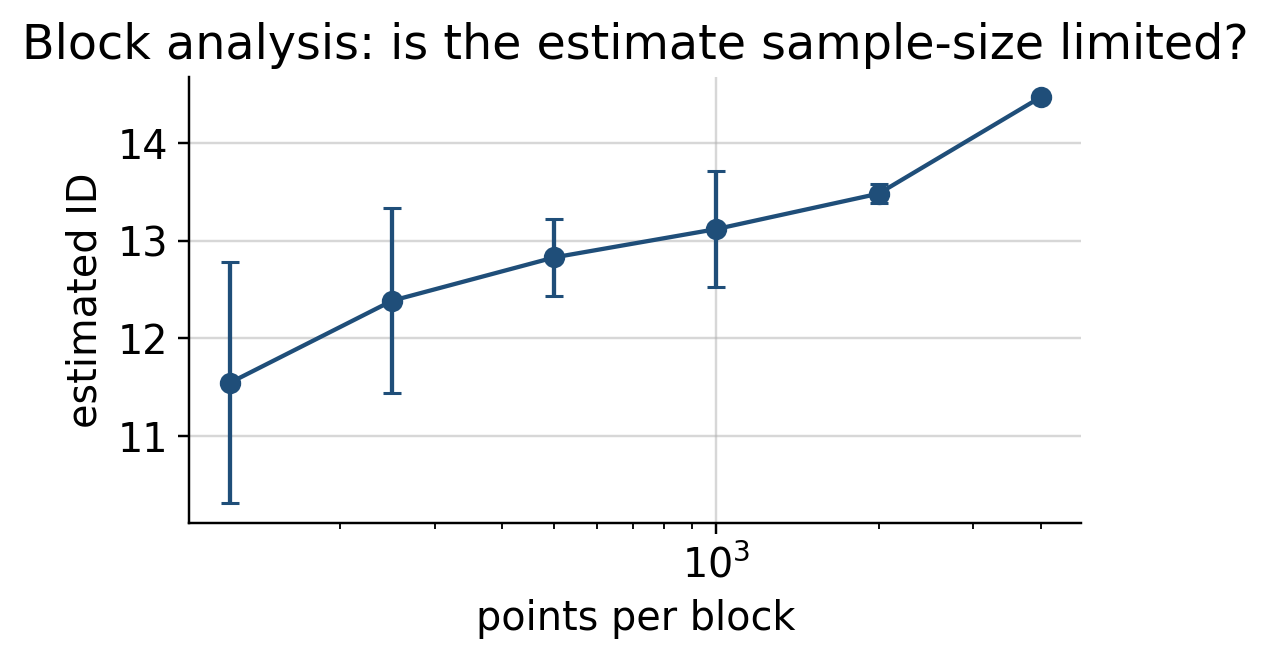

In [7]:
# TwoNN on a subsample, with the block-analysis stability curve.
# ~30 s at n=4000; brute-force neighbours are O(n^2 d).
sub = np.random.default_rng(lc.SEED).choice(len(Xz), min(4000, len(Xz)), replace=False)
val, diag = lc.id_with_scale_selection(Xz[sub], DEC["manifold.id_estimator"],
                                       DEC["manifold.id_scale_selection"])
rep = lc.id_report(val, diag)
print(f"TwoNN ID = {val:.2f}   lower_bound={rep['is_lower_bound']}")
print(rep["caveat"])
c = pd.DataFrame(diag.get("curve", []))
if len(c):
    display(c)
    plt.figure(figsize=(5, 3.2))
    plt.errorbar(c.block_size, c.id_mean, yerr=c.id_std, marker="o", lw=1.4, capsize=3, color="#1f4e79")
    plt.xscale("log"); plt.xlabel("points per block"); plt.ylabel("estimated ID")
    plt.title("Block analysis: is the estimate sample-size limited?"); plt.tight_layout(); plt.show()

## 5 · 2-D projections

`project2d` wraps PCA, UMAP and t-SNE behind one call and **caches to disk**,
because UMAP and t-SNE on 8,000 x 1024 take minutes and you will want to colour
the same layout by many different variables.

Read these honestly. PCA is a linear projection and distances in it mean
something. UMAP and t-SNE are neighbour-embedding methods: **cluster sizes and
between-cluster distances in them are not meaningful**, only local neighbourhood
structure is. A blob that looks isolated may not be.

In [8]:
import hashlib
def project2d(Z, method="pca", n=6000, seed=lc.SEED, force=False, **kw):
    # 2-D projection with disk caching. Returns (P, idx) for rows idx of Z.
    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(len(Z), min(n, len(Z)), replace=False))
    key = hashlib.md5(
        f"{method}{n}{seed}{Z.shape}{sorted(kw.items())}{float(Z[idx][:50].sum()):.6f}"
        .encode()).hexdigest()[:12]
    f = CACHE / f"proj_{method}_{key}.npz"
    if f.exists() and not force:
        d = np.load(f); print(f"cached -> {f.name}"); return d["P"], d["idx"]
    Zs = Z[idx]
    if method == "pca":
        from sklearn.decomposition import PCA
        P = PCA(n_components=2, random_state=seed).fit_transform(Zs)
    elif method == "umap":
        import umap
        P = umap.UMAP(n_components=2, random_state=seed,
                      n_neighbors=kw.get("n_neighbors", 30),
                      min_dist=kw.get("min_dist", .1)).fit_transform(Zs)
    elif method == "tsne":
        from sklearn.manifold import TSNE
        from sklearn.decomposition import PCA
        pre = PCA(n_components=min(50, Zs.shape[1]), random_state=seed).fit_transform(Zs)
        P = TSNE(n_components=2, random_state=seed,
                 perplexity=kw.get("perplexity", 30), init="pca").fit_transform(pre)
    else:
        raise ValueError(method)
    np.savez_compressed(f, P=P, idx=idx); print(f"computed -> {f.name}")
    return P, idx


def show(P, idx, colour, label, ax=None, cmap="viridis", q=(2, 98), s=4):
    c = np.asarray(colour)[idx]
    ok = np.isfinite(c)
    lo, hi = np.percentile(c[ok], q)
    ax = ax or plt.subplots(figsize=(5, 4.4))[1]
    h = ax.scatter(P[ok, 0], P[ok, 1], c=c[ok], s=s, cmap=cmap, vmin=lo, vmax=hi, lw=0)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.set_title(label, fontsize=9.5)
    plt.colorbar(h, ax=ax, fraction=.046, pad=.02)
    return ax

cached -> proj_pca_f6039c3caebe.npz


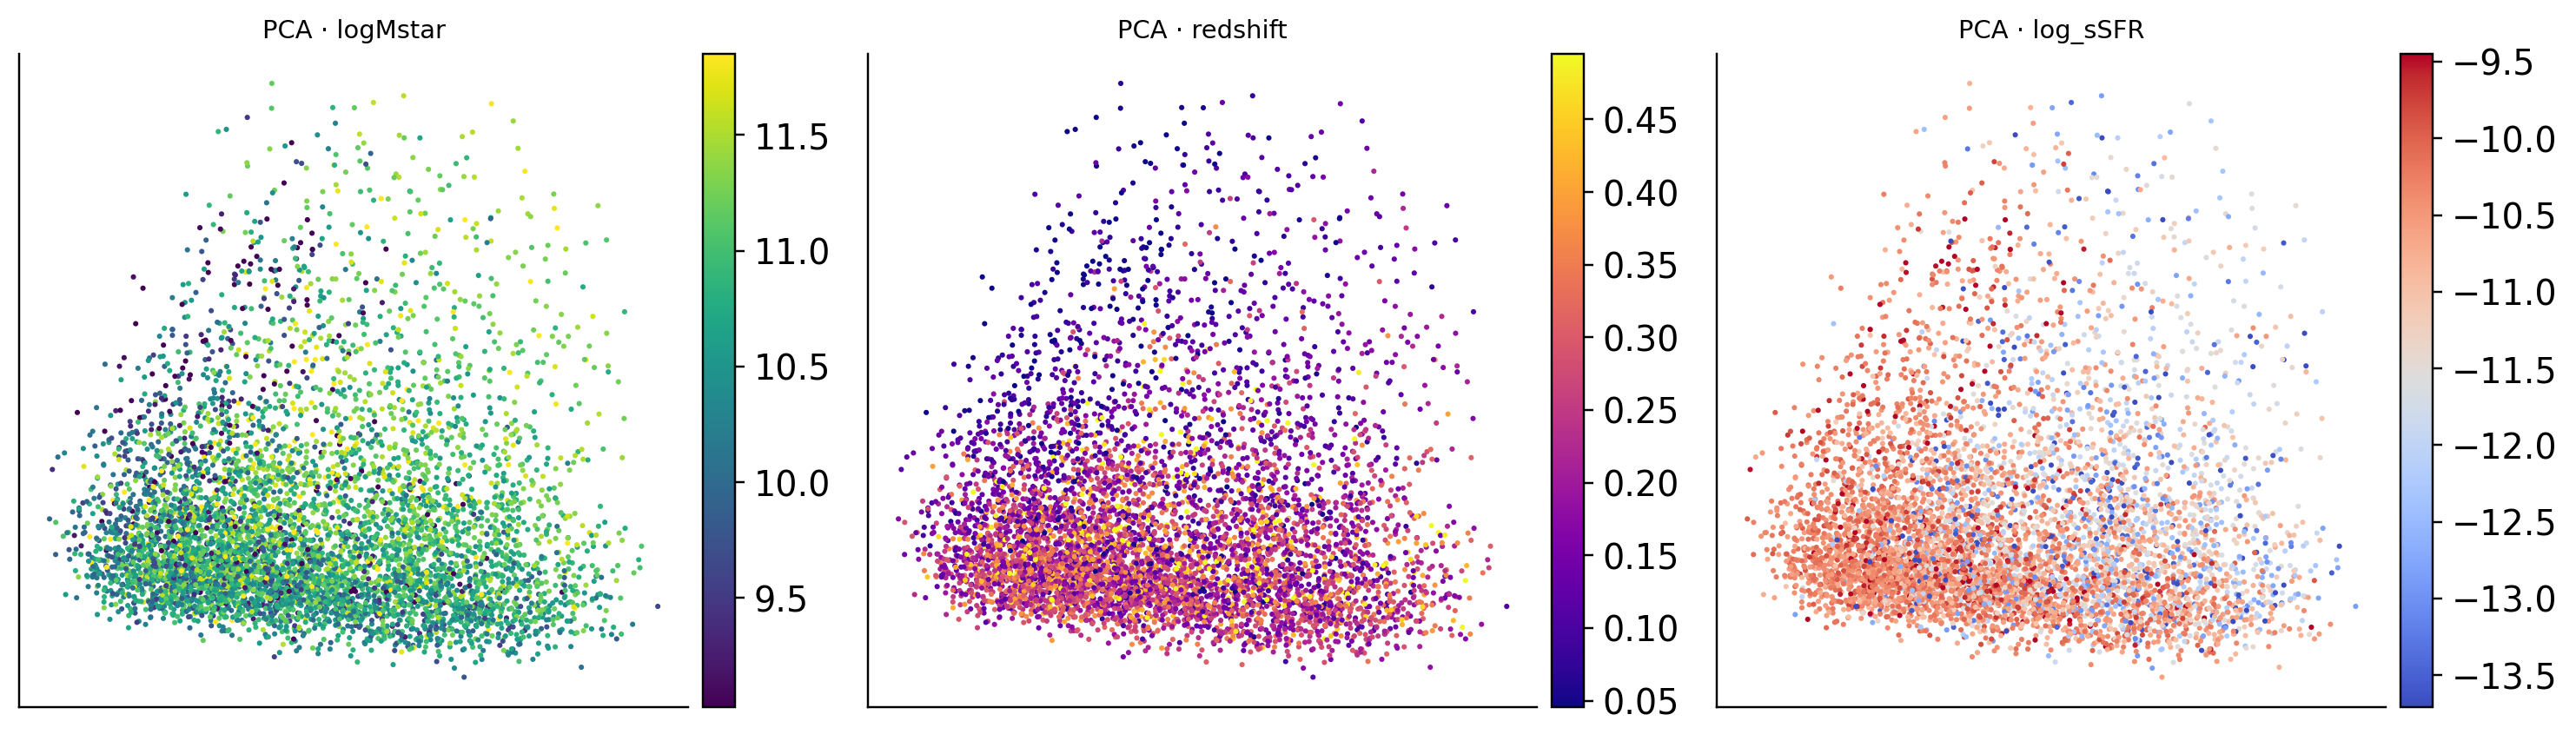

In [9]:
# PCA first — cheap, and distances in it are interpretable.
P, idx = project2d(Xz, "pca", n=6000)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
show(P, idx, Y["logMstar"],  f"PCA · {tnames['logMstar']}",  axes[0])
show(P, idx, Y["redshift"],  f"PCA · {tnames['redshift']}",  axes[1], cmap="plasma")
show(P, idx, Y["avgSfr"],    f"PCA · {tnames['avgSfr']}",    axes[2], cmap="coolwarm")
plt.tight_layout(); plt.show()

cached -> proj_umap_fbdd176d13a6.npz


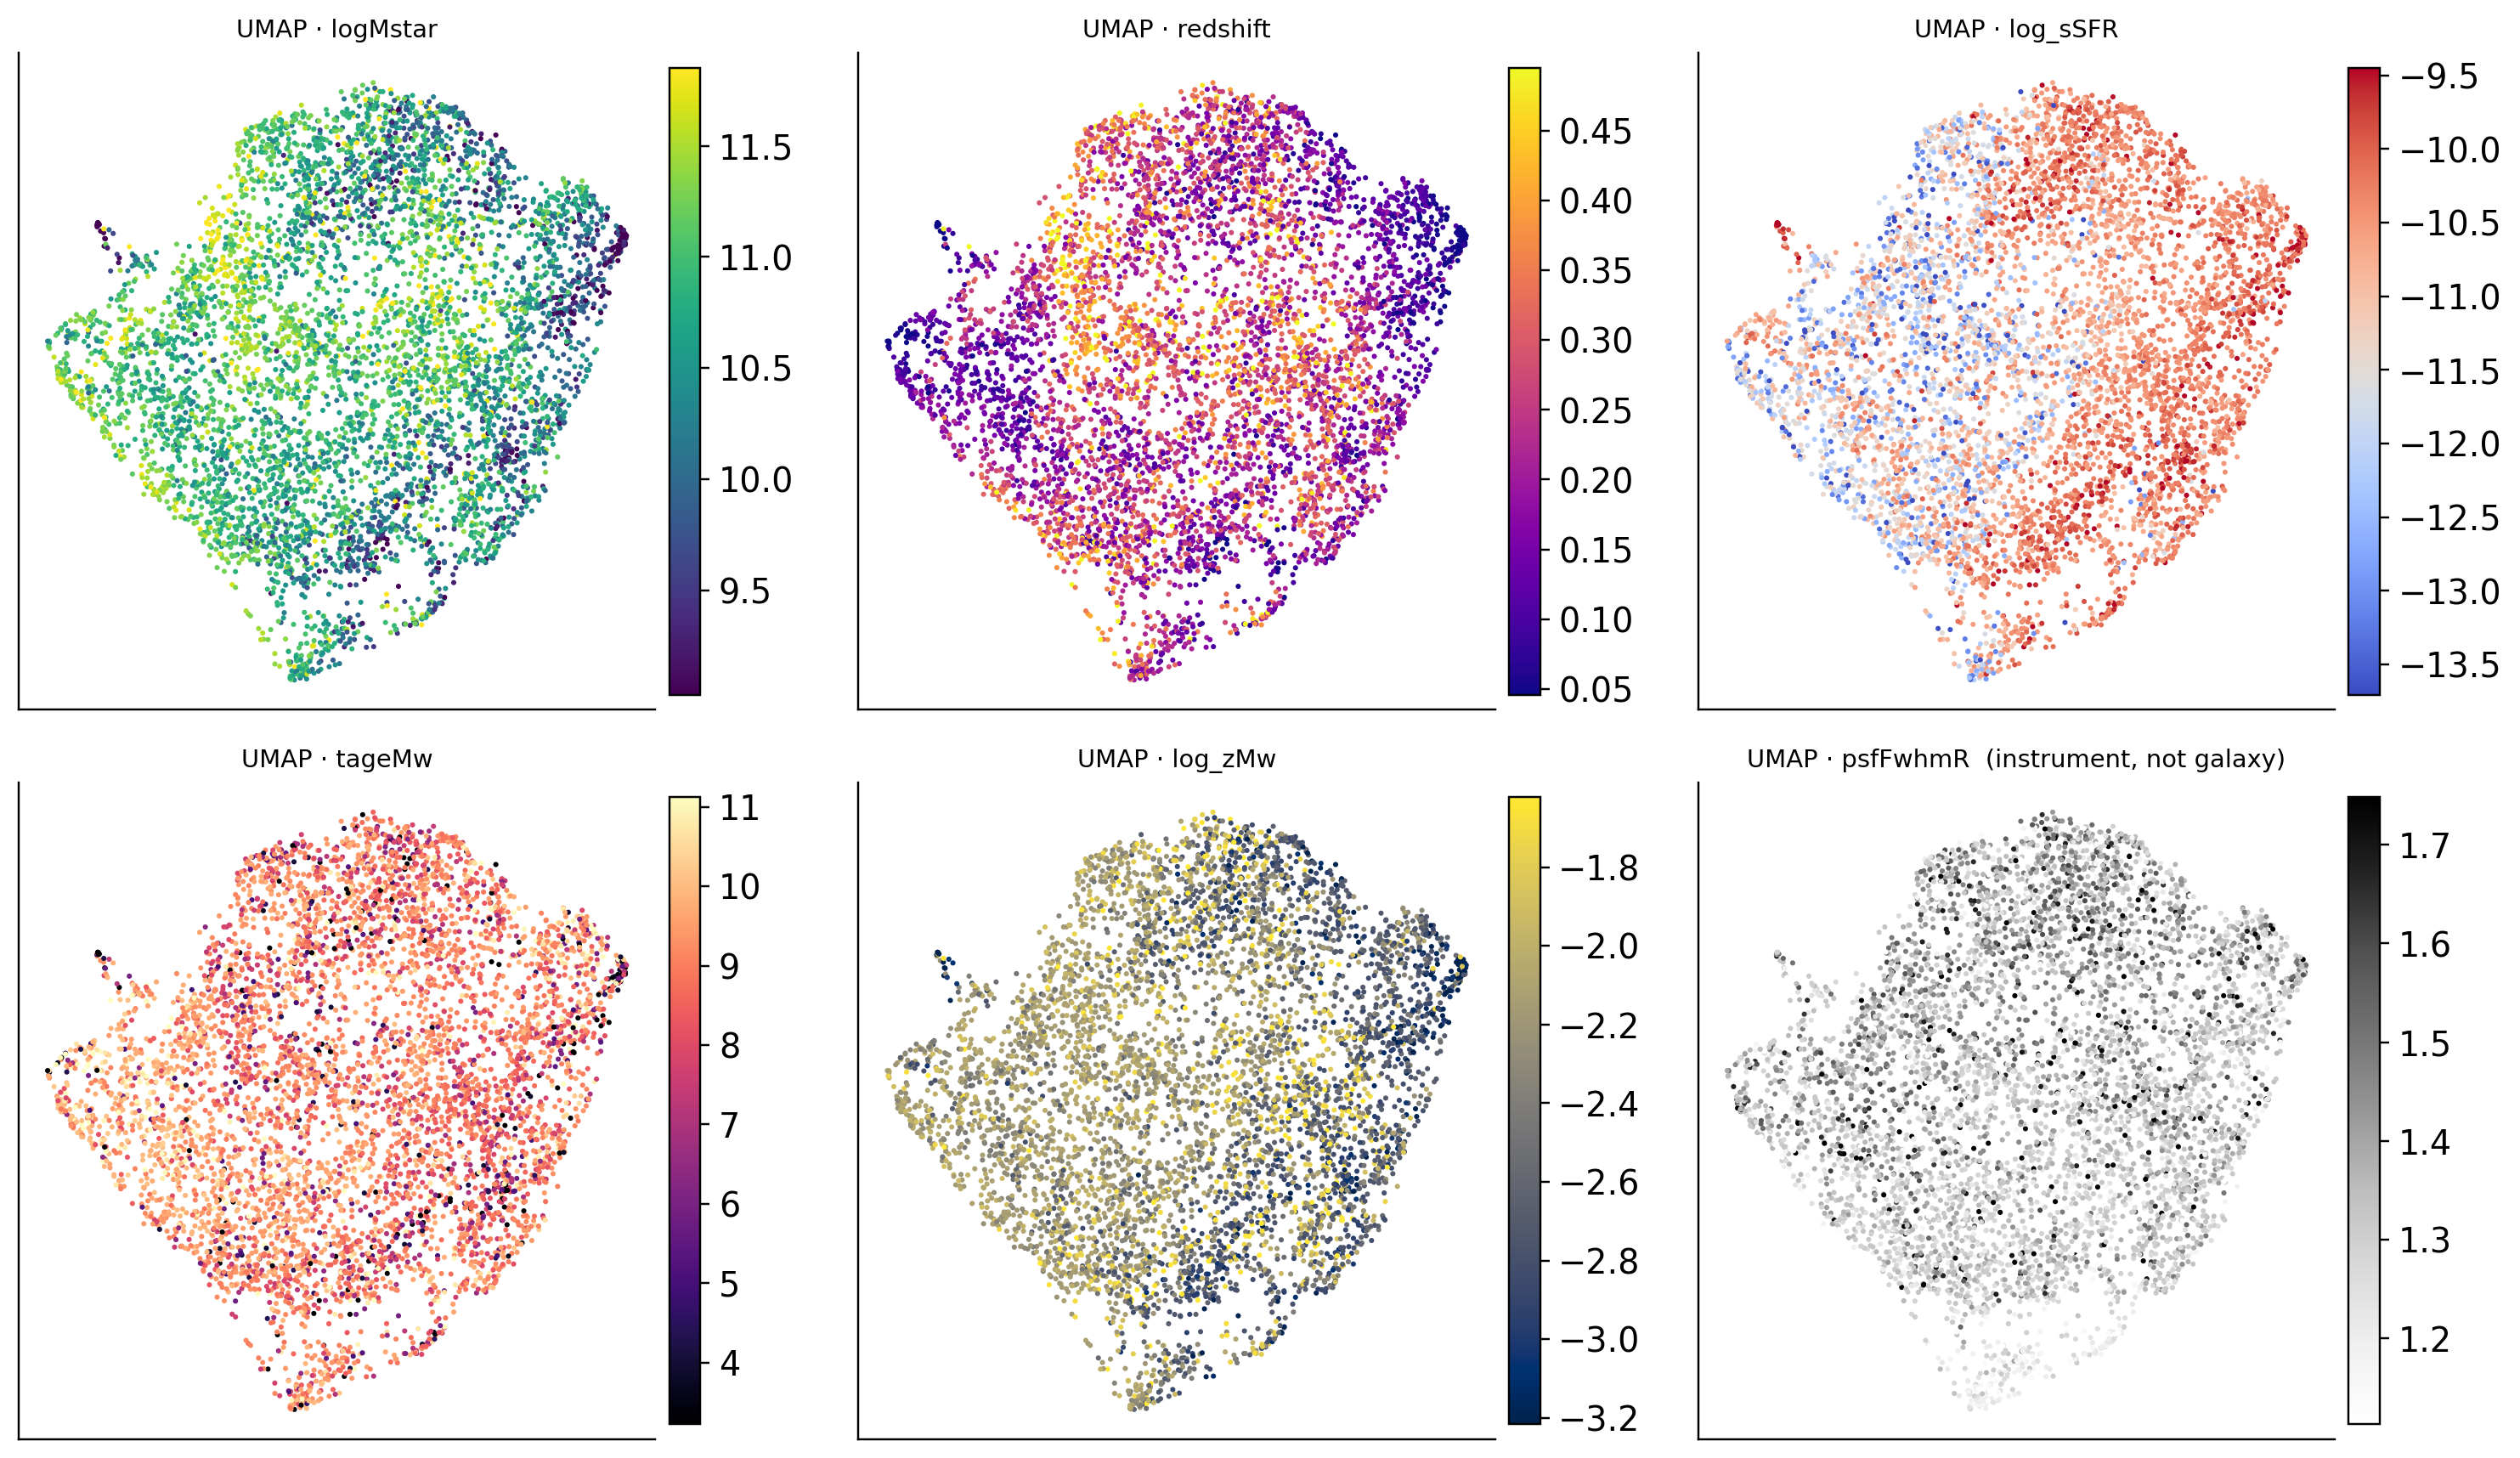

In [10]:
# HEAVY: UMAP on 6000 x 1024 is a few minutes the first time, then cached.
try:
    import umap  # noqa: F401
except ImportError:
    raise SystemExit("umap-learn is not installed in this kernel.\n"
                     "  uv pip install --python .venv/bin/python umap-learn\n"
                     "or skip to the next section - PCA above needs no extra package.")
P_u, idx_u = project2d(Xz, "umap", n=6000, n_neighbors=30, min_dist=0.1)
fig, axes = plt.subplots(2, 3, figsize=(13.5, 8))
for ax, (t, cm) in zip(axes.ravel(), [("logMstar","viridis"), ("redshift","plasma"),
                                      ("avgSfr","coolwarm"), ("tageMw","magma"),
                                      ("zMw","cividis")]):
    show(P_u, idx_u, Y[t], f"UMAP · {tnames[t]}", ax, cmap=cm)
show(P_u, idx_u, pd.to_numeric(cat["psfFwhmR"], errors="coerce").to_numpy(),
     "UMAP · psfFwhmR  (instrument, not galaxy)", axes.ravel()[5], cmap="Greys")
plt.tight_layout(); plt.show()

That last panel is the one to stare at. If the seeing (`psfFwhmR`) shows visible
structure in the same layout as the physical properties, the embedding is
carrying telescope as well as galaxy — which is exactly what
`probes.nuisance_probe_r2` quantifies, and what `domain_gap` projects out before
claiming anything about physics.

## 6 · Rotation orbits

Needs `manifold.rotation_orbit_embeddings` to be materialized. Shape is
`(n_galaxies, n_angles, 1024)`, with sidecars giving the sampled catalogue rows
and the angle grid.

A note that saves confusion later: the angles are a **uniform grid**, which
breaks TwoNN's local-Poisson assumption — every point's two neighbours are
near-equidistant, so a per-orbit TwoNN value inflates without bound and is not a
dimension. Use the harmonic spectrum and the linear participation ratio instead.
A single closed circle gives a participation ratio of exactly 2.

In [11]:
ORB = ROOT / "analyses/manifold/results/baseline/rotation_orbit_embeddings"
if (ORB / "rotation_orbit_embeddings.npy").exists():
    orb  = np.load(ORB / "rotation_orbit_embeddings.npy").astype(np.float64)
    rows = np.load(ORB / "orbit_row_index.npy")
    ang  = np.load(ORB / "orbit_angles_deg.npy")
    G, A, Dm = orb.shape
    prep = lc.EmbeddingPreprocessor(PREP).fit(orb.reshape(G*A, Dm))
    Zo   = prep.transform(orb.reshape(G*A, Dm)).reshape(G, A, Dm)
    print(f"{G} galaxies x {A} angles, step {ang[1]-ang[0]:.1f} deg")
else:
    print("not materialized yet — run:  lc run manifold.rotation_orbit_embeddings")

512 galaxies x 16 angles, step 22.5 deg


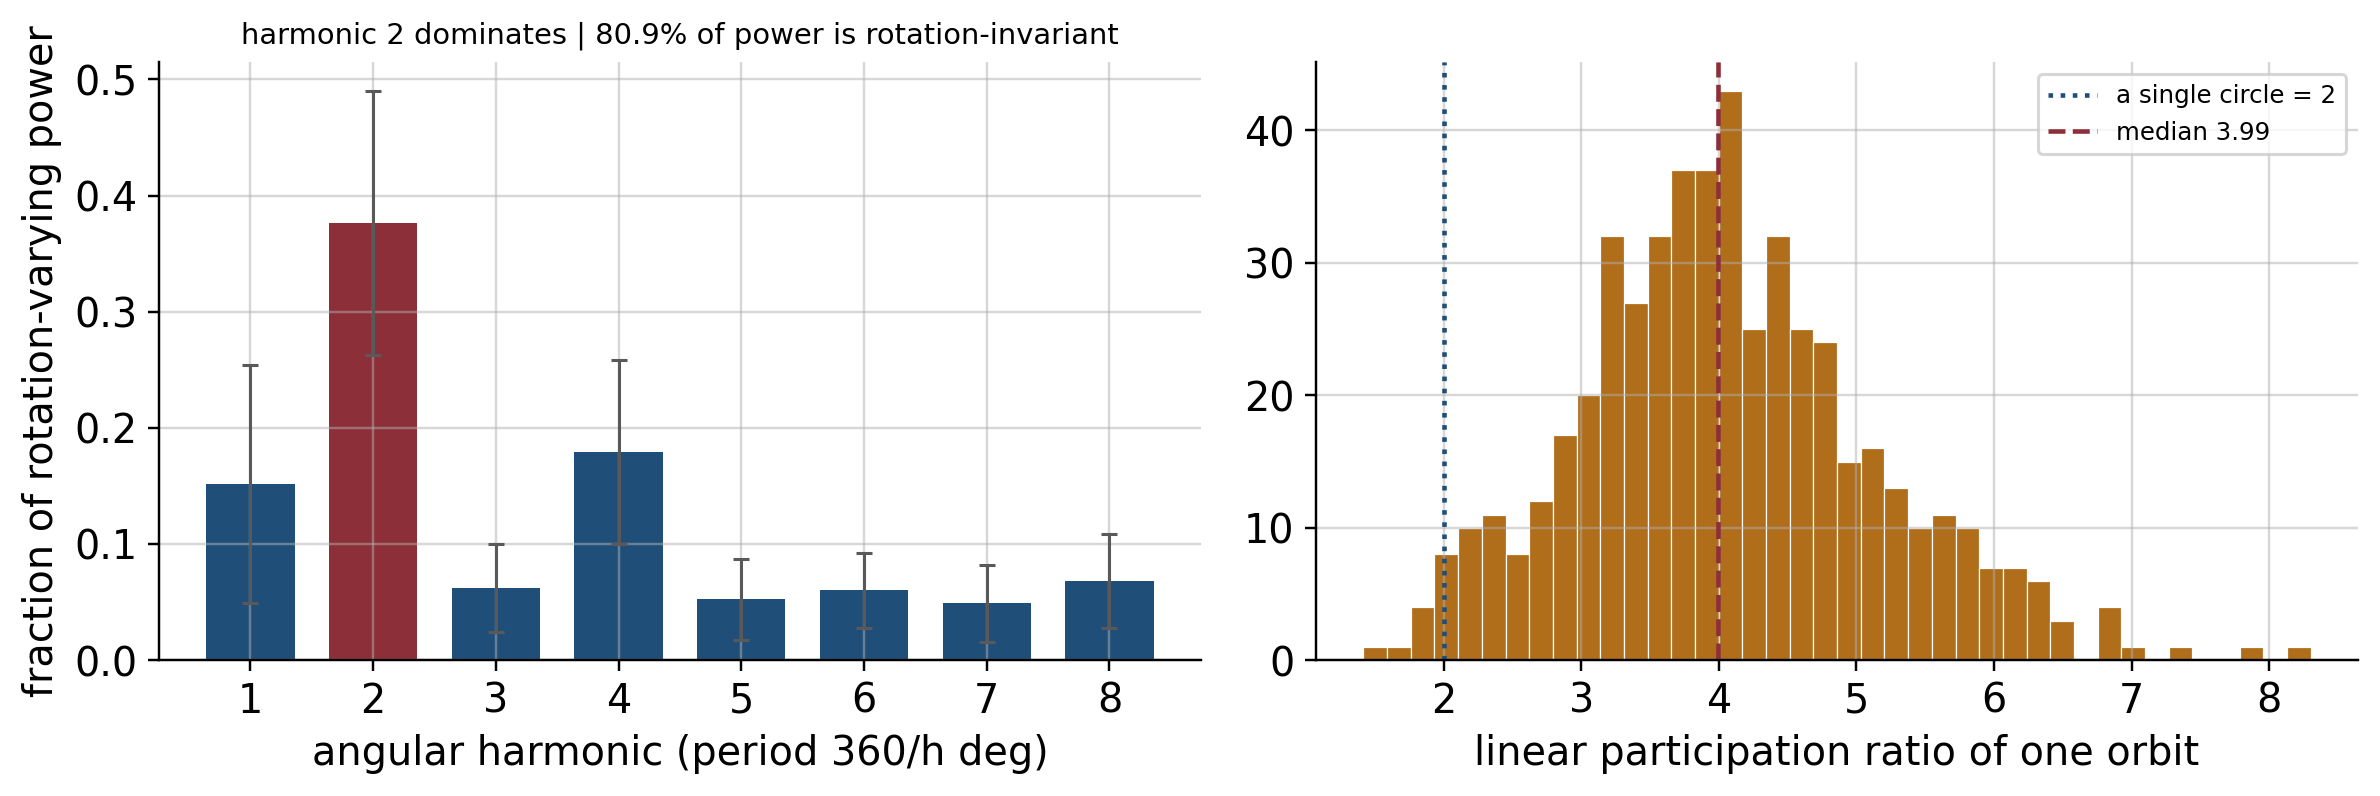

In [12]:
# Harmonic content: is the orbit a circle (all power at harmonic 1) or not?
F     = np.fft.rfft(Zo, axis=1) / A
power = (np.abs(F) ** 2).sum(axis=2)
frac  = power[:, 1:] / power[:, 1:].sum(1, keepdims=True)
inv   = power[:, 0] / power.sum(1)
pr_o  = np.array([lc._pca_participation_ratio(Zo[i]) for i in range(G)])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
h = np.arange(1, frac.shape[1] + 1)
ax[0].bar(h, frac.mean(0), yerr=frac.std(0), width=.72,
          color=["#8c2f39" if x == h[np.argmax(frac.mean(0))] else "#1f4e79" for x in h],
          error_kw={"elinewidth": 1, "ecolor": "0.35", "capsize": 2.5})
ax[0].set_xticks(h); ax[0].set_xlabel("angular harmonic (period 360/h deg)")
ax[0].set_ylabel("fraction of rotation-varying power")
ax[0].set_title(f"harmonic {h[np.argmax(frac.mean(0))]} dominates | "
                f"{inv.mean():.1%} of power is rotation-invariant", fontsize=9.5)
ax[1].hist(pr_o, bins=40, color="#b06d1a", edgecolor="white", lw=.4)
ax[1].axvline(2, ls=":", color="#1f4e79", label="a single circle = 2")
ax[1].axvline(np.median(pr_o), ls="--", color="#8c2f39", label=f"median {np.median(pr_o):.2f}")
ax[1].set_xlabel("linear participation ratio of one orbit"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [13]:
# Control: is any of this just interpolation blur? Multiples of 90 deg are exact
# rot90 (no resampling); everything else is interpolated.
ex = np.where(ang % 90 == 0)[0]; itp = np.where(ang % 90 != 0)[0]
r  = Zo - Zo.mean(1, keepdims=True)
print(f"mean deviation at exact rot90 angles : {np.linalg.norm(r[:, ex], axis=2).mean():.4f}")
print(f"mean deviation at interpolated angles: {np.linalg.norm(r[:, itp], axis=2).mean():.4f}")
Fe = np.fft.rfft(Zo[:, ex], axis=1) / len(ex)
pe = (np.abs(Fe) ** 2).sum(2); fe = pe[:, 1:] / pe[:, 1:].sum(1, keepdims=True)
print("\nspectrum from ONLY the exact angles (no interpolation anywhere):")
for i in range(fe.shape[1]):
    print(f"   harmonic {i+1}: {fe[:, i].mean():.4f}")

mean deviation at exact rot90 angles : 15.5037
mean deviation at interpolated angles: 15.4678

spectrum from ONLY the exact angles (no interpolation anywhere):
   harmonic 1: 0.2805
   harmonic 2: 0.7195


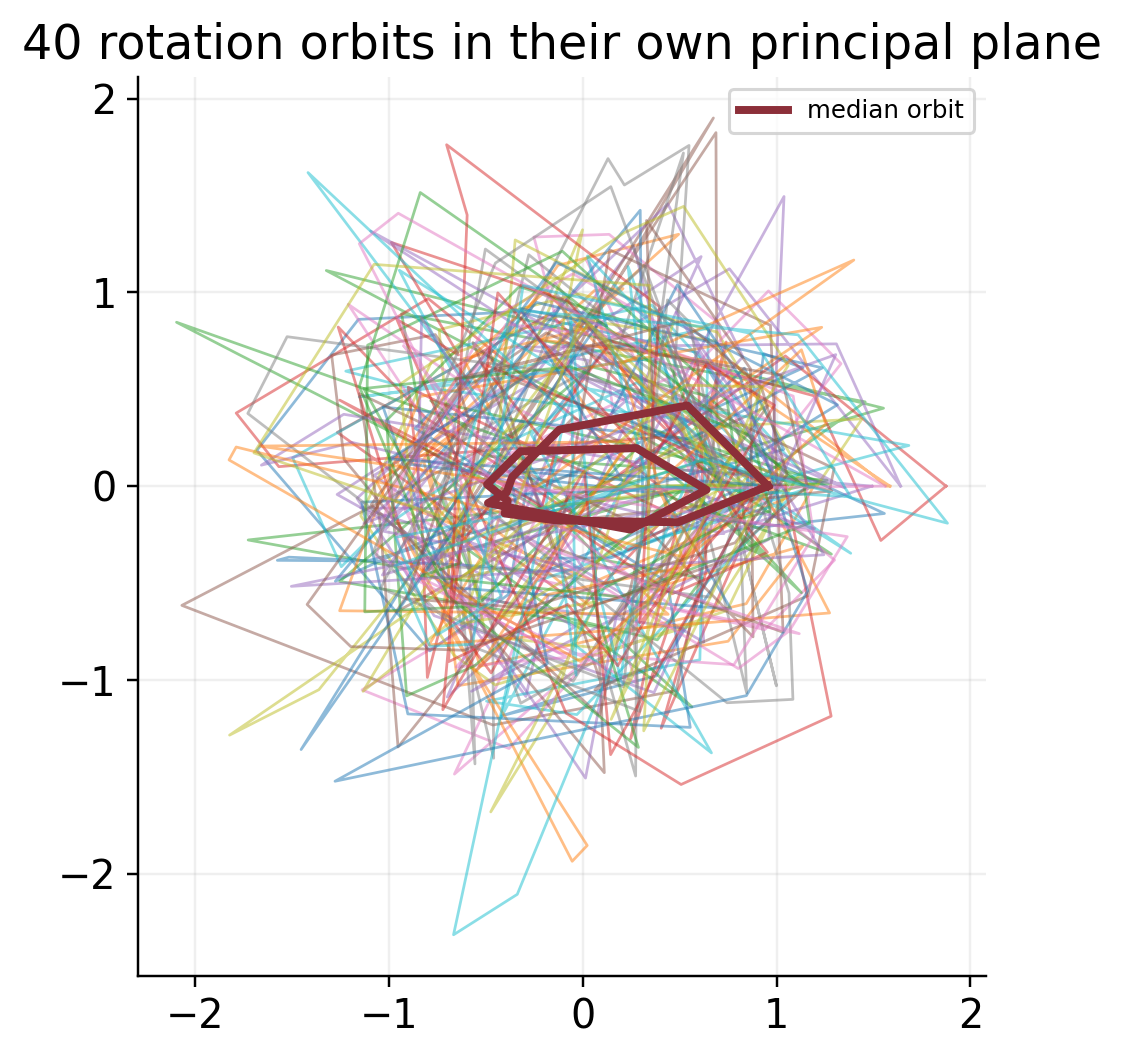

In [14]:
# Each orbit in its own principal plane, phase-aligned at 0 deg.
own = np.zeros((G, A, 2))
for i in range(G):
    _, _, Vt = np.linalg.svd(r[i], full_matrices=False)
    p = r[i] @ Vt[:2].T
    p = p / (np.linalg.norm(p, axis=1).mean() + 1e-12)
    th = np.arctan2(p[0, 1], p[0, 0]); c_, s_ = np.cos(-th), np.sin(-th)
    own[i] = p @ np.array([[c_, -s_], [s_, c_]]).T

plt.figure(figsize=(5, 5))
for i in range(40):
    q = np.vstack([own[i], own[i][:1]]); plt.plot(q[:, 0], q[:, 1], lw=.9, alpha=.5)
m = np.median(own, 0); m = np.vstack([m, m[:1]])
plt.plot(m[:, 0], m[:, 1], lw=2.6, color="#8c2f39", label="median orbit")
plt.gca().set_aspect("equal"); plt.legend(fontsize=8); plt.grid(alpha=.2)
plt.title("40 rotation orbits in their own principal plane"); plt.tight_layout(); plt.show()

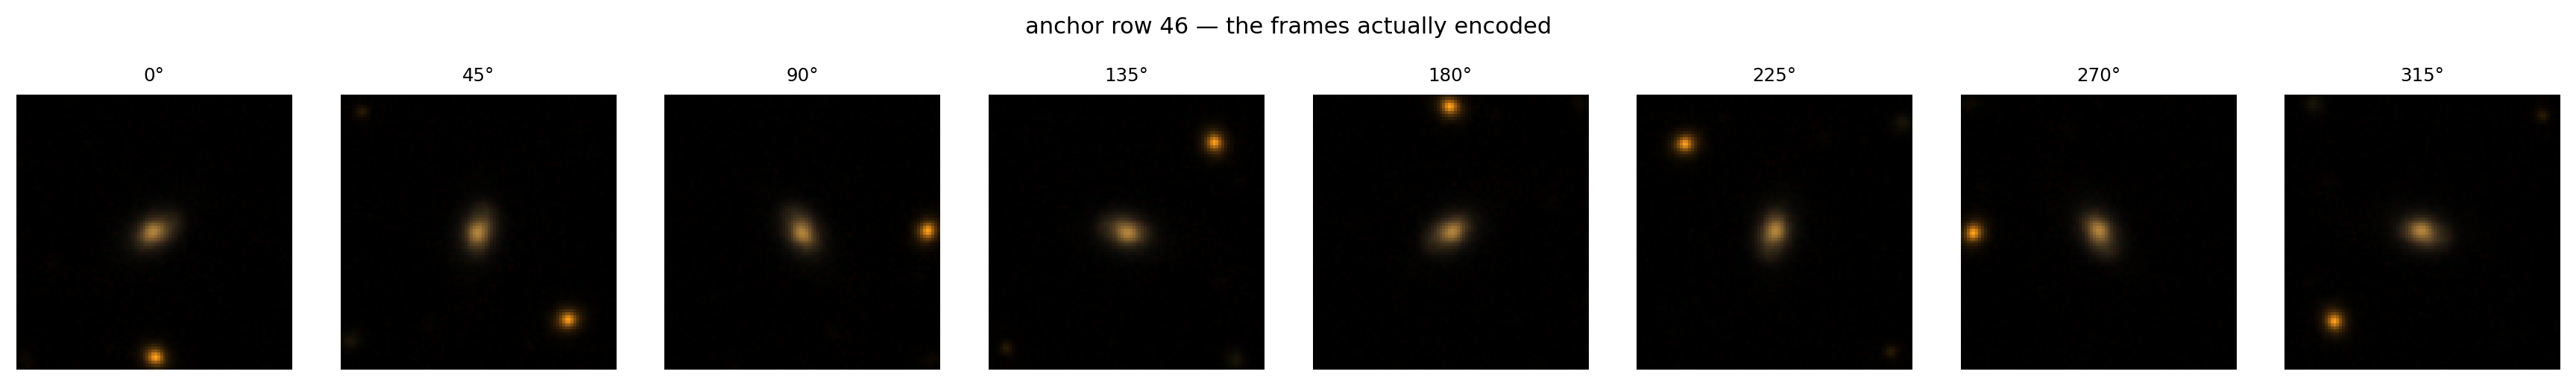

In [15]:
# Look at an actual galaxy and its rotations. anchor_img is memory-mapped;
# 160px cutouts leave margin so a rotated 96px crop is fully defined.
sys.path.insert(0, str(ROOT / "src" / "manifold"))
from encode_orbits import rotate_stack

gi  = 0
row = int(rows[gi])
img = np.asarray(D["anchor_img"][row], dtype=np.float32)
show_ang = ang[::max(1, A // 8)][:8]
fig, axes = plt.subplots(1, len(show_ang), figsize=(2.0*len(show_ang), 2.4))
for ax, a_ in zip(axes, show_ang):
    fr = rotate_stack(img, float(a_), DEC["manifold.rotation_interpolation"])
    rgb = np.stack([fr[2], fr[1], fr[0]], -1)          # i, r, g
    rgb = np.arcsinh(np.clip(rgb, 0, None) / 5.0)
    ax.imshow(rgb / (rgb.max() + 1e-9)); ax.set_title(f"{a_:.0f}°", fontsize=8)
    ax.axis("off")
plt.suptitle(f"anchor row {row} — the frames actually encoded", fontsize=10)
plt.tight_layout(); plt.show()

## 7 · Real vs simulated

ASTRID images carry **no PSF and no noise**. A classifier separating real from
simulated embeddings will therefore reach near-perfect AUC on that alone, which
is a statement about rendering, not about galaxies. The pipeline controls it by
matching the samples in mass and redshift and then projecting out the instrument
subspace the nuisance probes recover.

The limitation to keep attached to any number here: projection removes the part
of the instrument signature the probes capture **linearly**. It is not a
substitute for degrading the simulated images with a matched PSF and injected
noise, which was considered during scoping and declined on time grounds.

sim_quality_cuts='pathology_and_encl' keeps 9054 / 10000 simulated galaxies
cached -> proj_pca_631ea8cf5625.npz


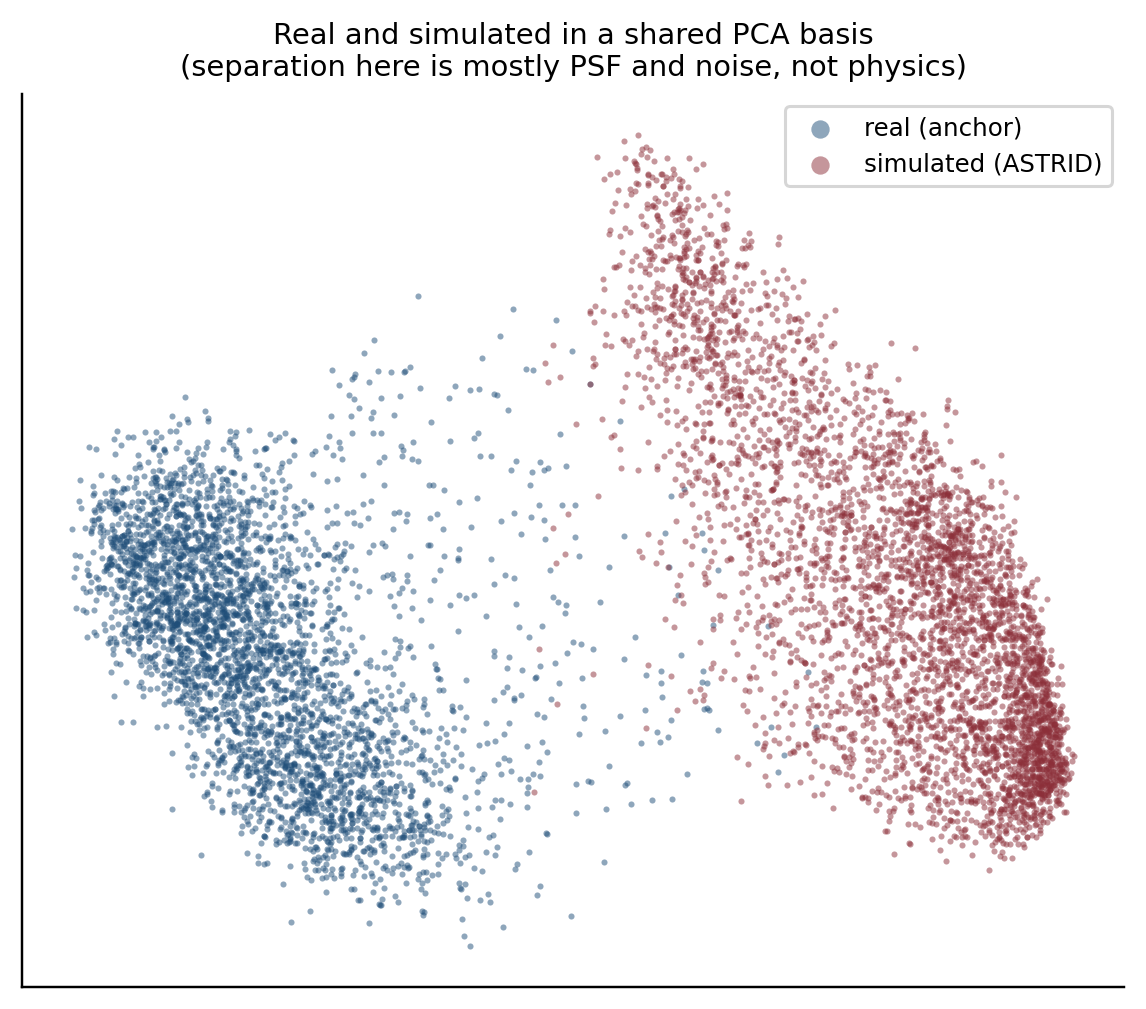

In [16]:
sim_mask = lc.sim_cut_mask(D["astrid_cat"], DEC["domain_gap.sim_quality_cuts"])
print(f"sim_quality_cuts='{DEC['domain_gap.sim_quality_cuts']}' keeps "
      f"{sim_mask.sum()} / {len(sim_mask)} simulated galaxies")

Xs   = D["astrid_emb"][sim_mask].astype(np.float64)
scat = D["astrid_cat"][sim_mask].reset_index(drop=True)

# Project both domains through ONE conditioning fitted on the pooled sample,
# otherwise the two clouds are drawn in different coordinate systems.
both = np.vstack([X, Xs])
dom  = np.r_[np.zeros(len(X), int), np.ones(len(Xs), int)]
Bz   = lc.EmbeddingPreprocessor(PREP).fit_transform(both)
P_b, idx_b = project2d(Bz, "pca", n=8000)

plt.figure(figsize=(5.4, 4.8))
d = dom[idx_b]
plt.scatter(P_b[d==0,0], P_b[d==0,1], s=4, lw=0, alpha=.5, label="real (anchor)",   color="#1f4e79")
plt.scatter(P_b[d==1,0], P_b[d==1,1], s=4, lw=0, alpha=.5, label="simulated (ASTRID)", color="#8c2f39")
plt.legend(markerscale=3, fontsize=8); plt.xticks([]); plt.yticks([]); plt.grid(False)
plt.title("Real and simulated in a shared PCA basis\n(separation here is mostly PSF and noise, not physics)", fontsize=9.5)
plt.tight_layout(); plt.show()

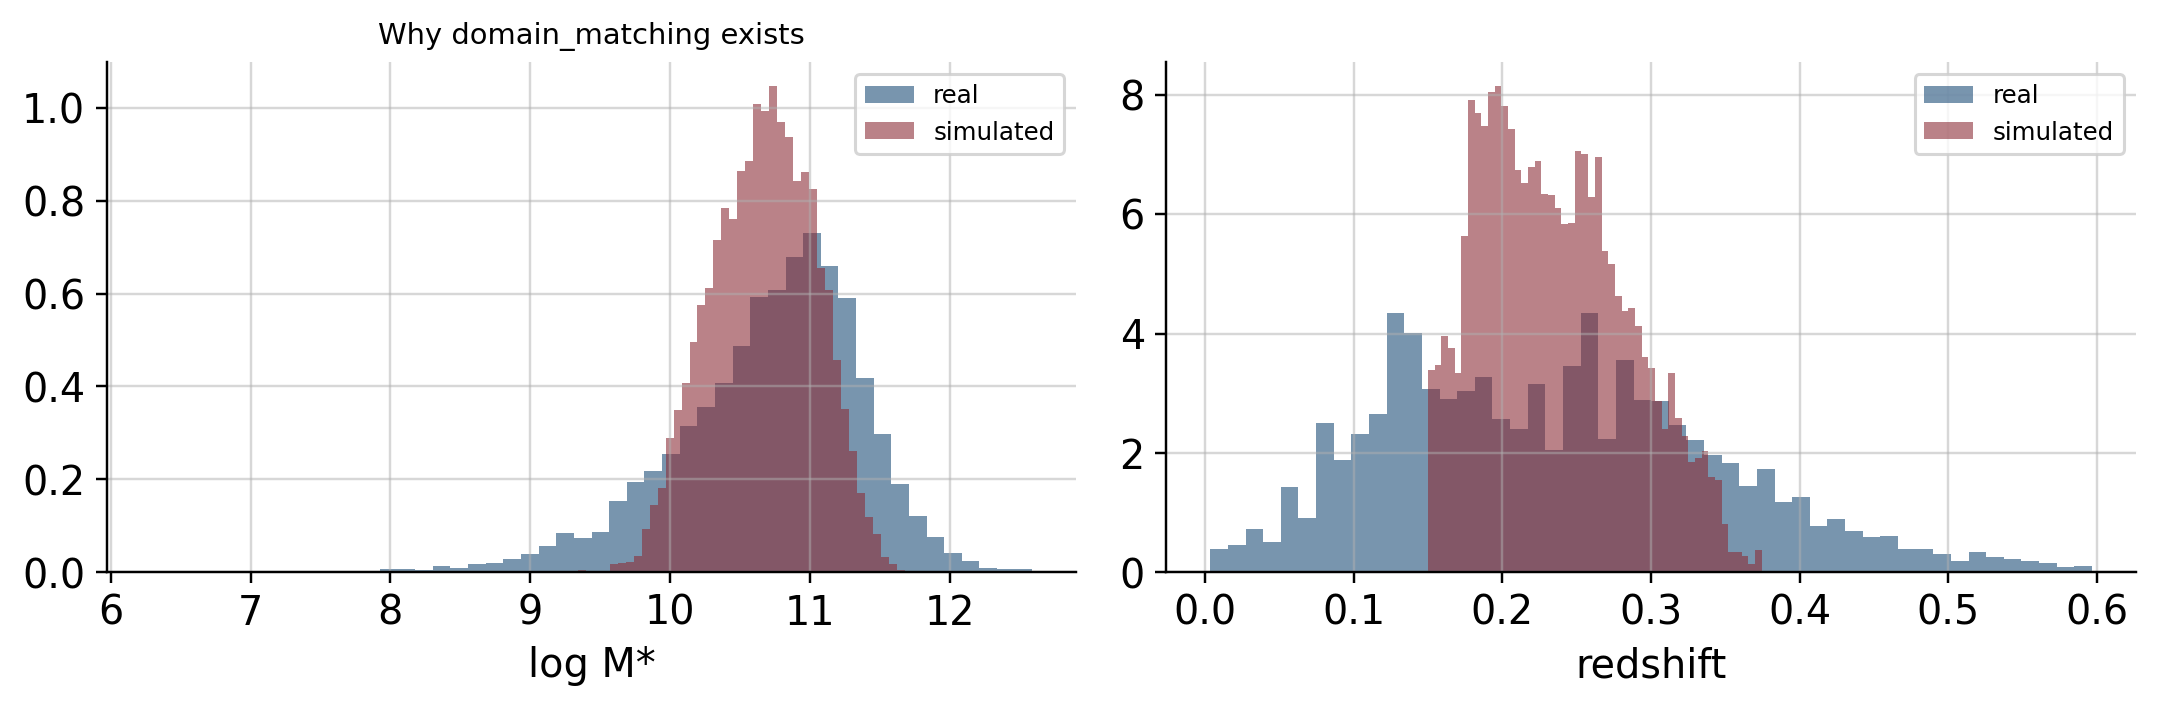

In [17]:
# The mass/redshift mismatch that makes matching necessary.
mr = pd.to_numeric(cat["logMstar"], errors="coerce")
ms = pd.to_numeric(scat[{"log_mstar_aper":"logMstarAper",
                         "log_mstar_total":"logMstarTotal"}[DEC["domain_gap.sim_mass_column"]]],
                   errors="coerce")
zr = pd.to_numeric(cat["redshift"], errors="coerce")
zs = pd.to_numeric(scat["redshift"], errors="coerce")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for a, (vr, vs, nm) in zip(ax, [(mr, ms, "log M*"), (zr, zs, "redshift")]):
    a.hist(vr.dropna(), bins=50, alpha=.6, density=True, label="real",      color="#1f4e79")
    a.hist(vs.dropna(), bins=50, alpha=.6, density=True, label="simulated", color="#8c2f39")
    a.set_xlabel(nm); a.legend(fontsize=8)
ax[0].set_title("Why domain_matching exists", fontsize=9.5)
plt.tight_layout(); plt.show()

In [18]:
# Nuisance directions, once probes.nuisance_probe_r2 is materialized.
NUI = ROOT / "analyses/probes/results/baseline/nuisance_probe_r2/nuisance_probe_r2.csv"
if NUI.exists():
    nu = pd.read_csv(NUI)
    display(nu[["variable", "r2_mean", "r2_std", "n_rows"]].sort_values("r2_mean", ascending=False))
    prep_b = lc.EmbeddingPreprocessor(PREP).fit(both)
    basis, info = lc.nuisance_basis(NUI, DEC["domain_gap.nuisance_subspace_dim"],
                                    DEC["domain_gap.nuisance_projection"], prep=prep_b)
    print(json.dumps({k: v for k, v in info.items() if k != "nuisance_probe_r2"}, indent=1)[:600])
    Bp = lc.project_out(Bz, basis)      # instrument subspace removed
    print("projected:", Bp.shape, "| removed", len(basis), "directions")
else:
    print("not materialized yet — run:  lc run probes.nuisance_probe_r2")

,variable,r2_mean,r2_std,n_rows
5,log_psfDepthR,0.729797,0.013232,8058
6,log_psfDepthI,0.645182,0.016615,8058
7,log_psfDepthZ,0.642241,0.010289,8058
4,log_psfDepthG,0.637687,0.015988,8058
14,log_nobsR,0.612491,0.016339,8058
16,log_nobsZ,0.585213,0.007889,8058
13,log_nobsG,0.574464,0.011634,8058
3,psfFwhmZ,0.490212,0.010998,8058
0,psfFwhmG,0.475448,0.008716,8058
1,psfFwhmR,0.470917,0.014458,8058


{
 "nuisance_projection": "probe_weight_span",
 "nuisance_subspace_dim_requested": 10,
 "n_directions": 10,
 "probe_directions_available": 17,
 "probe_span_rank": 17,
 "capped_at_available_rank": false,
 "singular_values": [
  2.2621782470675216,
  1.7526955536236934,
  1.4666215281217436,
  1.1790463363183954,
  1.1014852810831768,
  0.9156052112083685,
  0.8461014611671536,
  0.7415453996904303,
  0.7362262814288015,
  0.6661690368716998
 ],
 "nuisance_variables": [
  "psfFwhmG",
  "psfFwhmR",
  "psfFwhmI",
  "psfFwhmZ",
  "log_psfDepthG",
  "log_psfDepthR",
  "log_psfDepthI",
  "log_psfDept
projected: (17112, 1024) | removed 10 directions


## 8 · Quick probe scratchpad

`lc.SvdRidgeCV` is the pipeline's ridge: an inner-CV alpha grid, solved through
one eigendecomposition per fold instead of a refit per (alpha, fold) pair. It
agrees with `sklearn.RidgeCV` to 1e-15 on a matched splitter and is ~20x faster,
which is what makes exploration at 1024 features tolerable.

Anything you fit here is exploratory. The reported numbers come from `lc run`.

In [19]:
from sklearn.metrics import r2_score

def quick_probe(Z, y, split=None, prep=PREP):
    split = split or DEC["eval_split"]
    ok = np.isfinite(y)
    folds = lc.make_folds(int(ok.sum()), split)
    return lc.evaluate_probe(Z[ok], y[ok], folds, prep, lambda: lc.SvdRidgeCV())

res = {t: quick_probe(X, Y[t]) for t in lc.PHYSICAL_TARGETS}
display(pd.DataFrame(res).T[["score_mean", "score_std", "n_folds", "alpha_mean"]]
          .rename(columns={"score_mean": "R2", "score_std": "std"}))

,R2,std,n_folds,alpha_mean
logMstar,0.796974,0.006572,5.0,215.443469
avgSfr,0.548780,0.017979,5.0,1000.000000
tageMw,0.248296,0.017724,5.0,1230.886938
zMw,0.401256,0.025891,5.0,1000.000000
redshift,0.813691,0.010043,5.0,265.186552


In [20]:
# The bar that matters: photometry alone. Skill above this line is what the
# pixels add beyond a catalogue row.
Xp, pnames = lc.photometry_features(cat, DEC["probes.photometry_baseline_features"])
fin = np.isfinite(Xp).all(1)
rows = []
for t in lc.PHYSICAL_TARGETS:
    e = quick_probe(X, Y[t])["score_mean"]
    p = quick_probe(Xp[fin], Y[t][fin], prep="standardize")["score_mean"]
    rows.append({"target": tnames[t], "embedding": e, "photometry": p, "gain": e - p})
df = pd.DataFrame(rows)
display(df.style.format({"embedding": "{:.3f}", "photometry": "{:.3f}", "gain": "{:+.3f}"}))
print("photometry features:", pnames)

,target,embedding,photometry,gain
0,logMstar,0.797,0.665,+0.132
1,log_sSFR,0.549,0.469,+0.080
2,tageMw,0.248,0.139,+0.109
3,log_zMw,0.401,0.337,+0.065
4,redshift,0.814,0.681,+0.132


photometry features: ['magG', 'magR', 'magI', 'magZ', 'G-R', 'G-I', 'G-Z', 'R-I', 'R-Z', 'I-Z']


In [21]:
# Where the real artifacts live, and what still needs running.
import subprocess
print(subprocess.run(["lc", "status"], capture_output=True, text=True,
                     cwd=ROOT, env={**os.environ,
                     "PATH": f"{ROOT}/.venv/bin:{os.environ['PATH']}"}).stdout)
for sub in ("probes", "manifold", "domain_gap"):
    d = ROOT / "analyses" / sub / "results" / "baseline"
    if d.exists():
        for o in sorted(d.iterdir()):
            fs = [f.name for f in o.iterdir() if not f.name.startswith(".")]
            print(f"  {sub}/{o.name:32s} {fs}")


Universe baseline
  → alias   headline_probe_table
  → alias   headline_dimensionality
  → alias   headline_domain_gap
  ✸ stale   probes.probe_r2_physical
  ✸ stale   probes.probe_r2_photometry_baseline
  ✸ stale   probes.nuisance_probe_r2
  ✸ stale   probes.morphology_auc
  ✸ stale   probes.morphology_auc_photometry
  ✸ stale   probes.probe_comparison_plot
  ✸ stale   manifold.rotation_orbit_embeddings
  ✸ stale   manifold.orbit_fourier_spectrum
  ✸ stale   manifold.intrinsic_dim_full
  ✸ stale   manifold.intrinsic_dim_orbit
  ✸ stale   manifold.intrinsic_dim_quotient
  ✸ stale   manifold.id_comparison_plot
  ✸ stale   manifold.symbolic_expressions
  ✸ stale   manifold.symbolic_complexity_curve
  ✸ stale   manifold.symbolic_complexity_plot
  ✸ stale   manifold.symbolic_vs_linear_r2
  ✸ stale   domain_gap.raw_discriminability
  ✸ stale   domain_gap.matched_discriminability
  ✸ stale   domain_gap.residual_discriminability
  ✸ stale   domain_gap.probe_transfer_r2
  ✸ stale   domain_gap

### Notes for going further

- **Every decision has alternatives.** `astra.yaml` lists them with the reasoning.
  Trying one means adding a universe file, not editing code — e.g. a `prototype`
  universe with `orbit_subsample: n256` and `angle_grid: a8` is 2,048 encodes
  instead of 8,192.
- **`sr_n_coordinates` is an open question.** It sits at `k8` on no evidence and
  should be revisited against the measured `intrinsic_dim_quotient`.
- **`nuisance_subspace_dim` likewise.** If `residual_discriminability` disagrees
  between `d5` and `d20`, report it as a function of the dimension rather than at
  a single value.
- **Don't merge anchor and gzArm.** Different galaxies. Morphology comes only
  from gzArm, because the anchor sample's morphology columns are 1.9-3.2% covered.
- Anything you want to keep as a **result** has to become an output in
  `astra.yaml` with a recipe, so it gets a provenance manifest. Notebook output
  is exploration, not evidence.